In [42]:
import sys
sys.path.append('..')  # go up one level to project/

from typing import Dict, Mapping, Sequence, Tuple
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

# wordcloud of top labels across all movies, sized by global frequency.
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from helper import *

label_map_path = '/hehe/projects/gaze-corrected-semantics/jen_reference/data/masks/label_map.txt'
xml_dir = Path('/hehe/projects/gaze-corrected-semantics/jen_reference/data/masks/segmentation-xmls/')
movies = [
    'test2',
    'train01', 'train02', 'train03', 'train04', 'train05',
    'train06', 'train07', 'train08', 'train09', 'train10',
]

In [34]:
# loading in the label_map that shio made
shios_label_map = load_python_dict(label_map_path, 'label_map')

first, let's just take a look at the unique set of object labels used to mask the movies!

In [35]:
def parse_annotation_labels(
    annotation_file: str,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> set[str]:
    """Parse CVAT-style XML annotations and return unique mask labels only.

    This is much faster and lighter than parse_annotations when you only need
    the label vocabulary and not per-pixel label maps.
    """
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    labels: set[str] = set()
    for mask in root.findall('.//mask'):
        label = mask.get('label')
        if label is None:
            continue

        if strip:
            label = label.strip()
        if lowercase:
            label = label.lower()
        if drop_empty and label == "":
            continue

        labels.add(label)

    return labels

def load_movie_label_sets(
    movies: Sequence[str] | str,
    xml_dir: str | None = None,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> Dict[str, set[str]]:
    """Load unique labels per movie without constructing per-pixel arrays."""
    if isinstance(movies, str):
        movies = [movies]

    base_dir = xml_dir 
    movie_to_labels: Dict[str, set[str]] = {}

    for movie in movies:
        xml_path = f"{base_dir}/{movie}.xml"
        movie_to_labels[movie] = parse_annotation_labels(
            xml_path,
            lowercase=lowercase,
            strip=strip,
            drop_empty=drop_empty,
        )

    return movie_to_labels

def load_all_movie_labels(
    movies: Sequence[str] | str,
    xml_dir: str | None = None,
    *,
    lowercase: bool = False,
    strip: bool = True,
    drop_empty: bool = True,
) -> set[str]:
    """Return the union of labels used across all selected movies."""
    movie_to_labels = load_movie_label_sets(
        movies,
        xml_dir=xml_dir,
        lowercase=lowercase,
        strip=strip,
        drop_empty=drop_empty,
    )

    all_labels: set[str] = set()
    for labels in movie_to_labels.values():
        all_labels.update(labels)
    return all_labels

In [36]:
unique_labels_per_movie = load_movie_label_sets(movies=movies, xml_dir=xml_dir)

# how many unique labels were used per movie? 
for movie, labelset in unique_labels_per_movie.items():
    print(f"{movie}: {len(labelset)}")

test2: 134
train01: 220
train02: 202
train03: 147
train04: 137
train05: 157
train06: 187
train07: 169
train08: 143
train09: 143
train10: 185


In [47]:
# now, how many unique labels were used across ALL movies? 
all_labels = load_all_movie_labels(movies=movies, xml_dir=xml_dir)

# make a cleaned dictionary, either replacing the word with the value in label_map, or duplciating itself
label_map = {}
for label in all_labels:
    label_map[label] = shios_label_map.get(label, label)


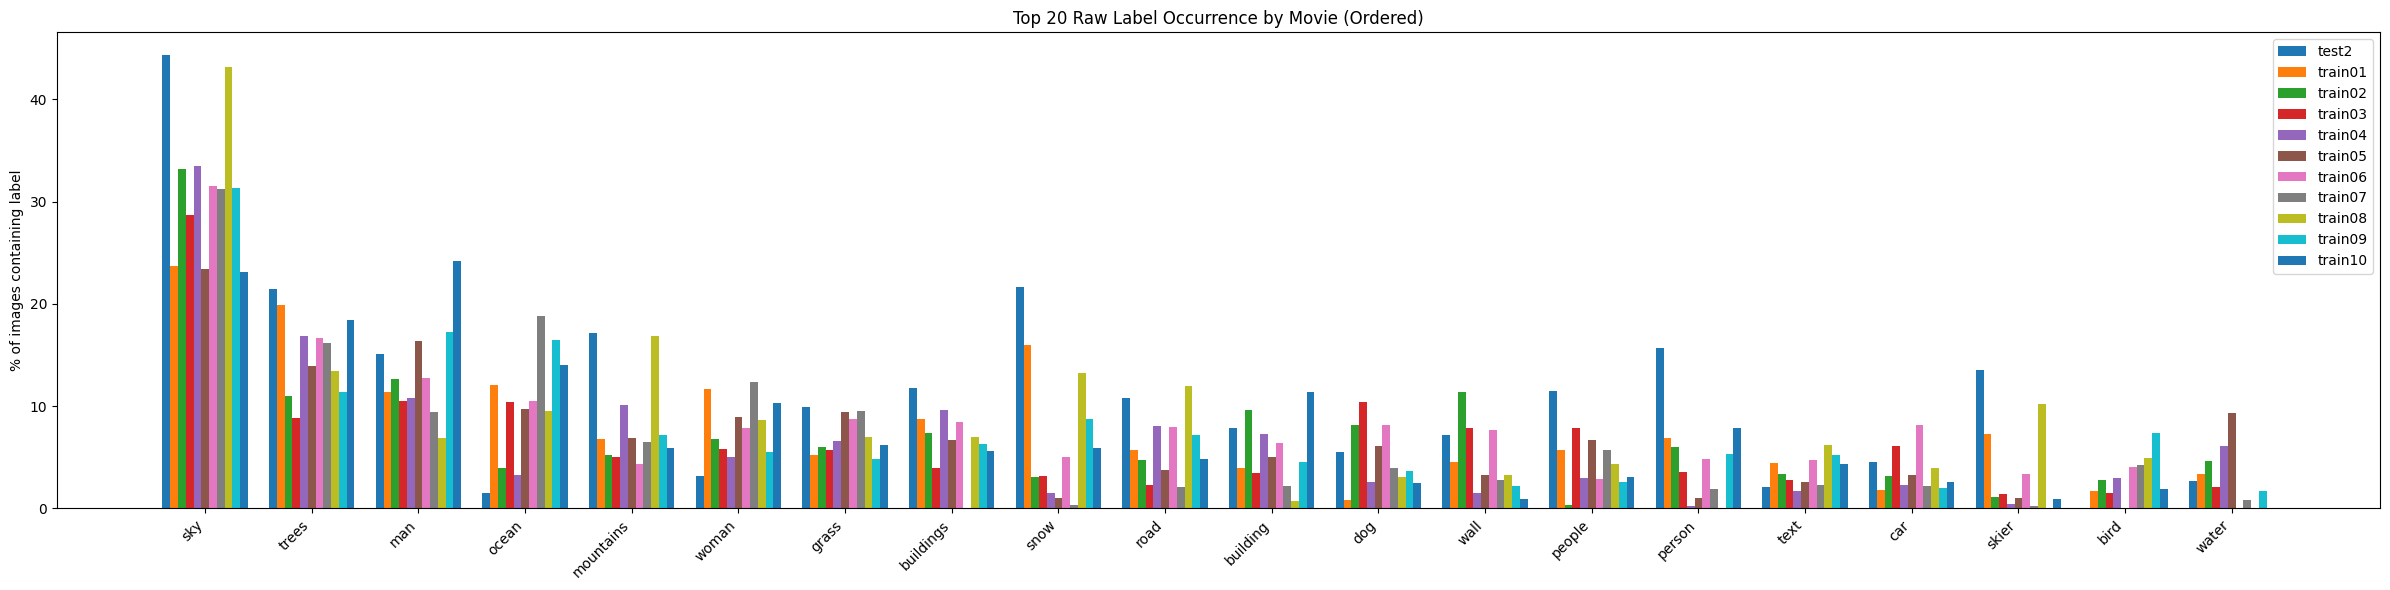

Top raw labels globally (in plotted order):
[('sky', 4977), ('trees', 2415), ('man', 2163), ('ocean', 1668), ('mountains', 1287), ('woman', 1286), ('grass', 1140), ('buildings', 1073), ('snow', 1069), ('road', 984), ('building', 905), ('dog', 803), ('wall', 752), ('people', 743), ('person', 716), ('text', 590), ('car', 580), ('skier', 509), ('bird', 476), ('water', 457)]


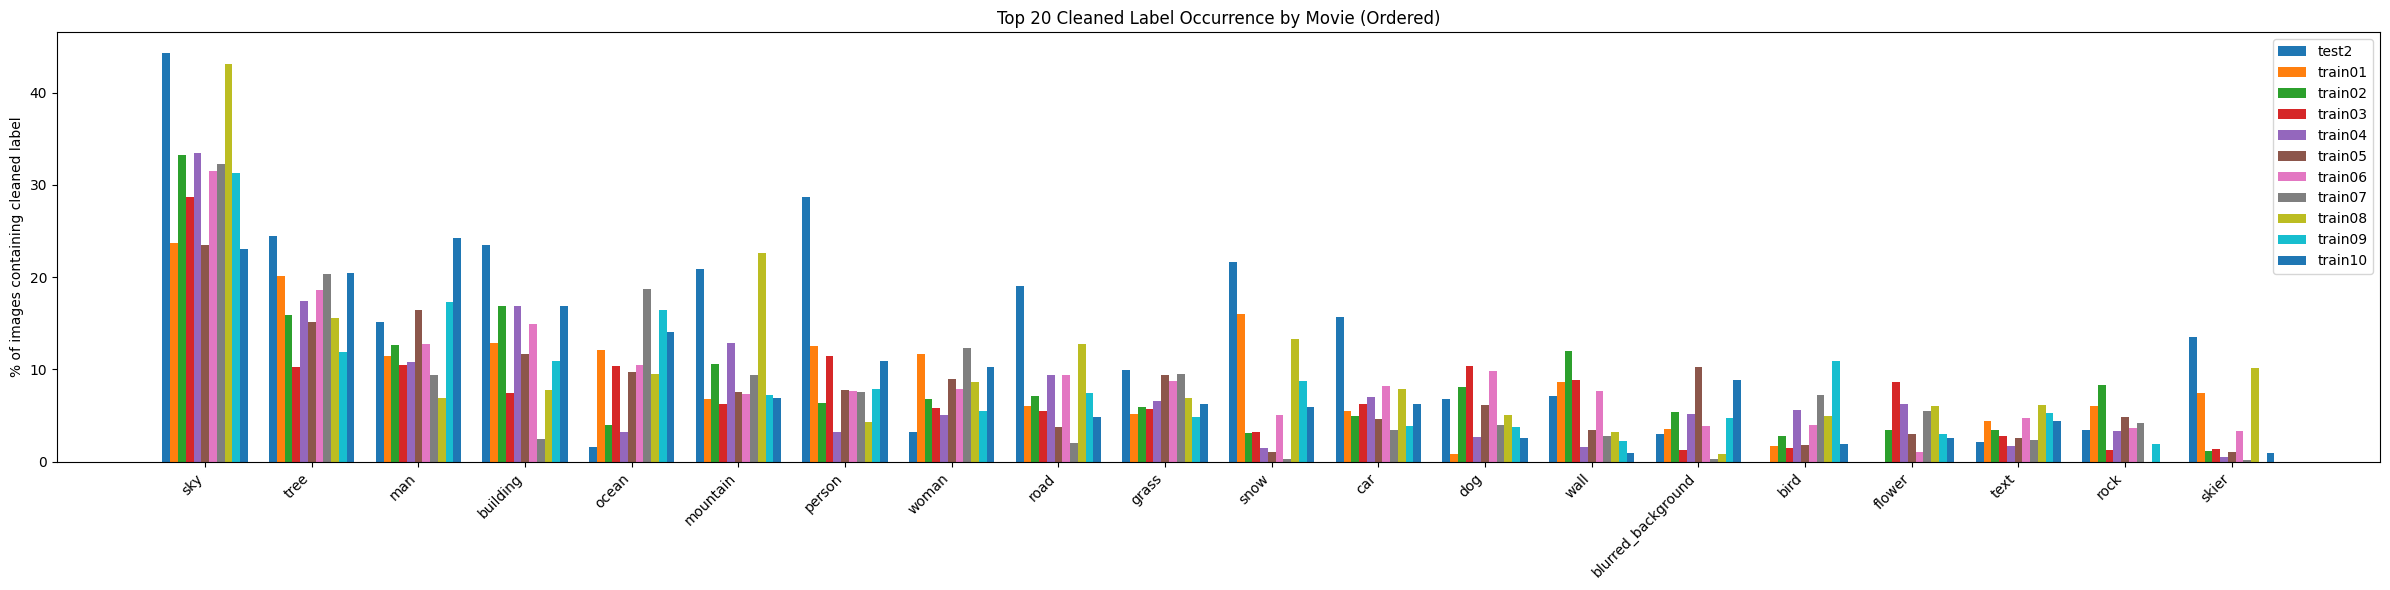

Top cleaned labels globally (in plotted order):
[('sky', 4992), ('tree', 2730), ('man', 2163), ('building', 2018), ('ocean', 1668), ('mountain', 1658), ('person', 1474), ('woman', 1287), ('road', 1204), ('grass', 1140), ('snow', 1069), ('car', 1016), ('dog', 868), ('wall', 839), ('blurred_background', 709), ('bird', 642), ('flower', 594), ('text', 590), ('rock', 541), ('skier', 511)]


In [40]:
# Plot the most common raw labels across all movies (top 20), ordered by global frequency.
def parse_movie_raw_label_counts(xml_path: Path) -> Counter:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    label_counts = Counter()

    for image in root.findall('.//image'):
        labels_in_image = set()
        for mask in image.findall('.//mask'):
            label = mask.get('label')
            if label is not None and label != '':
                labels_in_image.add(label)
        label_counts.update(labels_in_image)

    return label_counts

# get the raw label counts per movie
movie_raw_label_counts = {
    movie: parse_movie_raw_label_counts(xml_dir / f"{movie}.xml")
    for movie in movies
}

# then aggregate globally to find top labels for plotting
global_label_counts = Counter()
for counts in movie_raw_label_counts.values():
    global_label_counts.update(counts)

top_n = 20
top_labels = [label for label, _ in global_label_counts.most_common(top_n)]

# number of images per movie for percentage normalization.
movie_totals = {
    movie: len(ET.parse(xml_dir / f"{movie}.xml").getroot().findall(".//image"))
    for movie in movies
}

# Raw-label grouped bar plot in exact frequency order.
x = np.arange(len(top_labels))
width = 0.8 / max(len(movies), 1)

_, ax = plt.subplots(figsize=(max(14, len(top_labels) * 1.2), 6))
for i, movie in enumerate(movies):
    total = max(movie_totals[movie], 1)
    pct = [100 * movie_raw_label_counts[movie].get(label, 0) / total for label in top_labels]
    ax.bar(x + i * width, pct, width, label=movie)

ax.set_xticks(x + width * (len(movies) - 1) / 2)
ax.set_xticklabels(top_labels, rotation=45, ha="right")
ax.set_ylabel("% of images containing label")
ax.set_title(f"Top {top_n} Raw Label Occurrence by Movie (Ordered)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top raw labels globally (in plotted order):")
print(global_label_counts.most_common(top_n))

# Build cleaned per-movie counts using label_map, then plot the cleaned bar plot.
label_map = load_python_dict(label_map_path, "label_map")

movie_cleaned_label_counts = {}
for movie in movies:
    cleaned_counts = Counter()
    for raw_label, count in movie_raw_label_counts[movie].items():
        cleaned_label = label_map.get(raw_label, raw_label)
        if cleaned_label:
            cleaned_counts[cleaned_label] += count
    movie_cleaned_label_counts[movie] = cleaned_counts

global_cleaned_label_counts = Counter()
for counts in movie_cleaned_label_counts.values():
    global_cleaned_label_counts.update(counts)

top_cleaned_n = 20
top_cleaned_labels = [
    label for label, _ in global_cleaned_label_counts.most_common(top_cleaned_n)
]

x_clean = np.arange(len(top_cleaned_labels))
_, ax = plt.subplots(figsize=(max(14, len(top_cleaned_labels) * 1.2), 6))
for i, movie in enumerate(movies):
    total = max(movie_totals[movie], 1)
    pct = [
        100 * movie_cleaned_label_counts[movie].get(label, 0) / total
        for label in top_cleaned_labels
    ]
    ax.bar(x_clean + i * width, pct, width, label=movie)

ax.set_xticks(x_clean + width * (len(movies) - 1) / 2)
ax.set_xticklabels(top_cleaned_labels, rotation=45, ha="right")
ax.set_ylabel("% of images containing cleaned label")
ax.set_title(f"Top {top_cleaned_n} Cleaned Label Occurrence by Movie (Ordered)")
ax.legend() 
plt.tight_layout()
plt.show()

print("Top cleaned labels globally (in plotted order):")
print(global_cleaned_label_counts.most_common(top_cleaned_n))

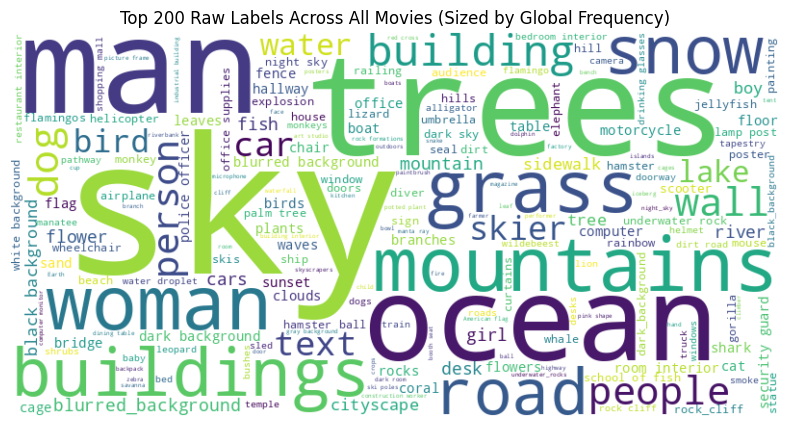

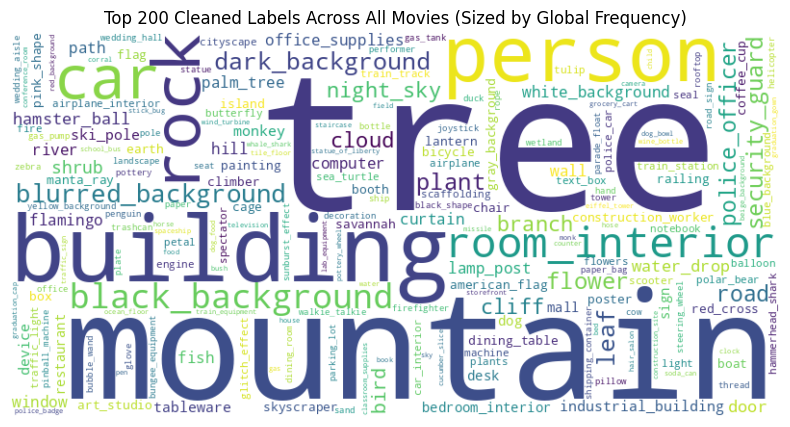

In [ ]:
# Get the top labels and their global frequencies
top_labels = [label for label, _ in global_label_counts.most_common(600)]
label_frequencies = {label: global_label_counts[label] for label in top_labels}

# Generate the wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(label_frequencies)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 200 Raw Labels Across All Movies (Sized by Global Frequency)')
plt.show()

label_map = load_python_dict(label_map_path, 'label_map')

# make a wordcloud for the top labels across all movies for the cleaned labels (after mapping to corrected labels using label_map), sized by global frequency.
# Get the top cleaned labels and their global frequencies
cleaned_label_counts = Counter()
for movie in movies:
    for label, count in movie_raw_label_counts[movie].items():
        cleaned_label = label_map.get(label)
        if cleaned_label is not None:
            cleaned_label_counts[cleaned_label] += count
top_cleaned_labels = [label for label, _ in cleaned_label_counts.most_common(600)]
cleaned_label_frequencies = {label: cleaned_label_counts[label] for label in top_cleaned_labels}

# Generate the wordcloud for cleaned labels
cleaned_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(cleaned_label_frequencies)
# Display the cleaned wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(cleaned_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 200 Cleaned Labels Across All Movies (Sized by Global Frequency)')
plt.show()



cool, that makes sense. now let's look at the masks for some images?

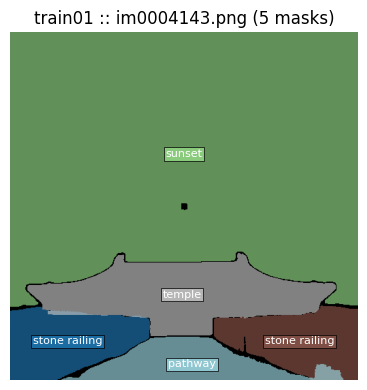

In [64]:
# Plot XML masks for one frame on a black 512x512 canvas with per-mask labels.
movie = "train01"
image_selector = "im0004143.png"  # use image filename or integer image id

xml_path = xml_dir / f"{movie}.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

def decode_cvat_rle(rle_text: str, width: int, height: int) -> np.ndarray:
    counts = [int(v.strip()) for v in rle_text.split(",") if v.strip()]
    flat = np.zeros(width * height, dtype=np.uint8)
    idx = 0
    value = 0  # CVAT RLE starts with background run length

    for count in counts:
        end = min(idx + count, flat.size)
        if value == 1 and end > idx:
            flat[idx:end] = 1
        idx = end
        value = 1 - value
        if idx >= flat.size:
            break

    return flat.reshape((height, width))

images = root.findall(".//image")
if isinstance(image_selector, int):
    image_node = next((im for im in images if int(im.get("id", "-1")) == image_selector), None)
else:
    image_node = next((im for im in images if im.get("name") == image_selector), None)

if image_node is None:
    available = [im.get("name", "") for im in images[:10]]
    raise ValueError(f"Image {image_selector!r} not found in {xml_path.name}. Sample names: {available}")

canvas_h, canvas_w = 512, 512
canvas = np.zeros((canvas_h, canvas_w, 3), dtype=float)
mask_nodes = image_node.findall("mask")

if not mask_nodes:
    print(f"No masks found for {movie} / {image_node.get('name')}")
else:
    cmap = plt.get_cmap("tab20", max(len(mask_nodes), 1))
    label_positions = []

    for i, mask_node in enumerate(mask_nodes):
        label = mask_node.get("label", "unknown")
        rle = mask_node.get("rle")
        left = int(mask_node.get("left", "0"))
        top = int(mask_node.get("top", "0"))
        width = int(mask_node.get("width", "0"))
        height = int(mask_node.get("height", "0"))

        if not rle or width <= 0 or height <= 0:
            continue

        crop_mask = decode_cvat_rle(rle, width, height).astype(bool)

        x0 = max(left, 0)
        y0 = max(top, 0)
        x1 = min(left + width, canvas_w)
        y1 = min(top + height, canvas_h)
        if x1 <= x0 or y1 <= y0:
            continue

        crop_x0 = x0 - left
        crop_y0 = y0 - top
        crop_x1 = crop_x0 + (x1 - x0)
        crop_y1 = crop_y0 + (y1 - y0)
        roi_mask = crop_mask[crop_y0:crop_y1, crop_x0:crop_x1]
        if not np.any(roi_mask):
            continue

        color = np.array(cmap(i)[:3])
        roi = canvas[y0:y1, x0:x1]
        roi[roi_mask] = 0.35 * roi[roi_mask] + 0.65 * color

        ys, xs = np.nonzero(roi_mask)
        cx = x0 + float(xs.mean())
        cy = y0 + float(ys.mean())
        label_positions.append((label, cx, cy, color))

    plt.figure(figsize=(4, 4))
    plt.imshow(canvas)
    for label, cx, cy, color in label_positions:
        plt.text(
            cx,
            cy,
            label,
            color="white",
            fontsize=8,
            ha="center",
            va="center",
            bbox={
                "facecolor": (color[0], color[1], color[2], 0.75),
                "edgecolor": "black",
                "linewidth": 0.5,
                "pad": 1.2,
            },
        )

    plt.title(f"{movie} :: {image_node.get('name')} ({len(label_positions)} masks)")
    plt.xlim(0, 511)
    plt.ylim(511, 0)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

cool, now let's make OHE 

In [ ]:
def build_binary_design_matrix(xml_path: Path, resolver) -> pd.DataFrame:
    """create a binary design matrix with rows as images and columns as features, 
    where a 1 indicates the presence of a feature in that image according to the masks. 
    The resolver function maps raw mask labels to desired feature names, 
    allowing for label normalization or grouping.
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()
    rows = {}

    for image in root.findall('.//image'):
        image_name = image.get('name', image.get('id', 'unknown'))
        features = set()
        for mask in image.findall('.//mask'):
            raw_label = mask.get('label')
            feature = resolver(raw_label)
            if feature is not None:
                features.add(feature)
        rows[image_name] = features

    all_features = sorted({f for features in rows.values() for f in features})
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(
        {
            image_name: {feature: int(feature in features) for feature in all_features}
            for image_name, features in rows.items()
        }
    ).T
    df.index.name = 'image'
    return df

In [61]:
movie_files = {movie: xml_dir / f'{movie}.xml' for movie in movies}

missing_xml = [movie for movie, path in movie_files.items() if not path.exists()]
if missing_xml:
    raise FileNotFoundError(f'Missing XML files: {missing_xml}')

movie_category_counts = {}
movie_totals = {}
category_design_matrices = {}

def normalized_label_resolver(raw_label: str | None):
    if raw_label is None:
        return 'unlabeled'
    return label_map.get(raw_label)

label_design_matrices = {
    movie: build_binary_design_matrix(path, normalized_label_resolver)
    for movie, path in movie_files.items()
}

In [62]:
# get all of the labels across the entire movie set
all_normalized_labels = sorted({
    label
    for dm in label_design_matrices.values()
    for label in dm.columns
})

# reindex each design matrix to have the same columns (all normalized labels), filling missing columns with 0s
label_design_matrices = {
    movie: dm.reindex(columns=all_normalized_labels, fill_value=0)
    for movie, dm in label_design_matrices.items()
}

# downsample to a TR so we can make our features!
downsampled_label_design_matrices = {
    movie: downsample_design_matrix(dm, step=10)
    for movie, dm in label_design_matrices.items()
}


print('Normalized-label design matrix shapes:')
for movie in movies:
    full_shape = label_design_matrices[movie].shape
    down_shape = downsampled_label_design_matrices[movie].shape
    print(f"  {movie}: full={full_shape}, downsampled={down_shape}")

# save downsampled_label_design_matrices as features, "visual_20260315_corrected-labels"
labelstosave = {}
for movie, df in downsampled_label_design_matrices.items():
    print(df.values.shape)
    featurewords = df.columns.tolist()
    labelstosave[movie] = df.values

np.savez('/hehe/projects/gaze-corrected-semantics/jen_reference/data/features/visual_segmented-objects.npz', **labelstosave)
np.save('/hehe/projects/gaze-corrected-semantics/jen_reference/data/features/visual_segmented-objects_featurewords.npy',featurewords)


/hehe/projects/gaze-corrected-semantics/jen_reference/notebooks/../helper.py:107: RuntimeWarning: invalid value encountered in divide
  val = window * np.sin(np.pi * t) * np.sin(np.pi * t / window) / (np.pi**2 * t**2)


Normalized-label design matrix shapes:
  test2: full=(907, 578), downsampled=(91, 578)
  train01: full=(1478, 578), downsampled=(148, 578)
  train02: full=(1524, 578), downsampled=(153, 578)
  train03: full=(1497, 578), downsampled=(150, 578)
  train04: full=(1479, 578), downsampled=(148, 578)
  train05: full=(1603, 578), downsampled=(161, 578)
  train06: full=(1492, 578), downsampled=(150, 578)
  train07: full=(1497, 578), downsampled=(150, 578)
  train08: full=(1453, 578), downsampled=(146, 578)
  train09: full=(1563, 578), downsampled=(157, 578)
  train10: full=(1577, 578), downsampled=(158, 578)
(91, 578)
(148, 578)
(153, 578)
(150, 578)
(148, 578)
(161, 578)
(150, 578)
(150, 578)
(146, 578)
(157, 578)
(158, 578)


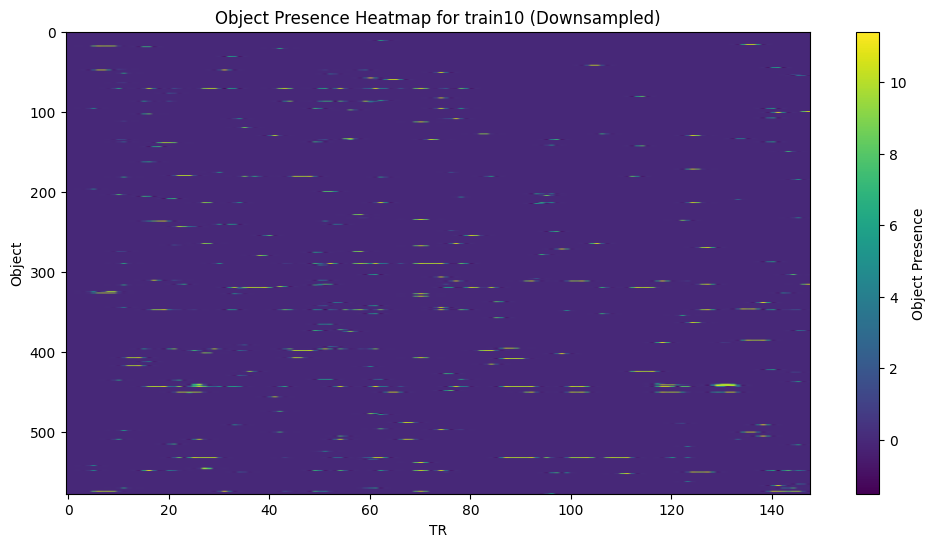

In [63]:
# imshow the downsampled design matrix for one movie to verify it looks correct
plt.figure(figsize=(12,6))
plt.imshow(downsampled_label_design_matrices['train01'].values.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Object Presence')
plt.title(f'Object Presence Heatmap for {movie} (Downsampled)')
plt.xlabel('TR')
plt.ylabel('Object')
plt.show()
plt.close()

In [ ]:
# okay NOW let's add eyetracking to it, and save out the features for ZXI and KLR